# Downstream Evaluation: RankMe Evolution → Multilingual Performance

**Research question:** *Does the shape of the RankMe trajectory during pre-training predict downstream multilingual performance? Specifically: does the point where compression begins (onset) and how long it lasts (duration) correlate with accuracy on m-MMLU and XCOPA?*

**Models:** FuxiTranyu-8B · Apertus-8B-2509  
**Benchmarks:** m-MMLU (5-shot, 8 languages) · XCOPA (0-shot, 5 languages)

### What this notebook does
1. **Phase identification** — detects two training phases from the RankMe curve: an *entropy-seeking* phase (RankMe ↑, the model builds richer representations) and a *compression-seeking* phase (RankMe ↓, the model specializes and compresses). For each phase, **onset** is the token count (in billions) where the phase begins, and **duration** is how many tokens it lasts. Works with `fuxi.csv` alone.
2. **Grokking detection** — finds the first checkpoint where accuracy rises more than 15 percentage points above random-chance and stays there for at least 2 consecutive checkpoints. This marks the point where the model transitions from near-random guessing to genuinely solving the task. Requires downstream eval results.
3. **Correlation analysis** — Spearman + Pearson tests: *does an earlier or longer compression phase predict earlier or higher accuracy?* Computed separately per task (m-MMLU / XCOPA), never pooled across tasks.
4. **Plots** — RankMe trajectories, phase overlays (shaded regions drawn on the RankMe curve that visually mark where each phase occurs), dual-axis accuracy curves, and a correlation scatter per task.

> **Note:** Cells that require downstream evaluation results degrade gracefully if `results/eval/` is empty. Run `evaluate.py` (or `submit_eval.sh`) first, then rerun this notebook.

In [1]:
import warnings

import pandas as pd

from utils import (
    load_config,
    load_rankme_data, load_eval_data,
    compute_phases, compute_grokking, compute_correlations_table,
    plot_rankme_phases, plot_overlay, plot_correlation_scatter,
)

warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


> 🚨 **Set `MODEL` before running.** Change the variable in the next cell to `"fuxi"` or `"apertus"`. Do not run all cells without doing this — the CSV path, last layer, and model label all derive from that single variable.

In [2]:
MODEL = "fuxi"   # ← "fuxi" or "apertus"

cfg = load_config(MODEL)
RANKME_CSV          = cfg["rankme_csv"]
MERGED_CSV          = cfg["merged_csv"]
LAYER               = cfg["layer"]
AGGREGATION         = cfg["aggregation"]
MODEL_LABEL         = cfg["model_label"]
GROKKING_THRESHOLD  = cfg["grokking_threshold"]
GROKKING_MIN_CONSEC = cfg["grokking_min_consec"]
RANDOM_CHANCE       = cfg["random_chance"]
TASK_LANGUAGES      = cfg["task_languages"]
PLOTS_DIR           = cfg["plots_dir"]

print(f"Model: {MODEL_LABEL}  |  Layer: {LAYER}  |  Aggregation: {AGGREGATION}")

Model: FuxiTranyu-8B  |  Layer: layer_29  |  Aggregation: last


## Data

Two separate sources are loaded:

- **`fuxi.csv` / `apertus.csv`** — RankMe geometry metrics produced by `geometry_analysis.py` for all model checkpoints, all languages, and all layers. Used for phase identification and phase plots. The working slice (`layer_29`, `agg=last`) gives one RankMe value per (checkpoint, language) pair across the full training run.

- **`fuxi_merged.csv` / `apertus_merged.csv`** — downstream accuracy merged with geometry metrics, produced by `merge_results.py` after running evaluation on the cluster. Only contains the checkpoints that have been evaluated. Used for grokking detection, correlation analysis, and overlay plots.

The phase plots use the full geometry data (all checkpoints). The accuracy-based plots use only the evaluated checkpoints — which is why these plots become more meaningful after the full evaluation run.

In [3]:
df_rankme, df_layer, checkpoints_all, token_counts, langs_sorted = load_rankme_data(RANKME_CSV, LAYER, AGGREGATION)
df_eval, EVAL_AVAILABLE = load_eval_data(MERGED_CSV)

Loaded RankMe: 45,240 rows — 58 checkpoints, 13 languages
Working slice : layer_29, agg=last → 754 rows
Loaded eval: 39 records — 2 task(s), 3 checkpoint(s)


In [4]:
df_phases = compute_phases(df_layer, checkpoints_all, token_counts)

display_cols = ["language", "peak_tokens",
                "entropy_onset_tokens", "entropy_duration_tokens",
                "compression_onset_tokens", "compression_duration_tokens"]
print(df_phases[display_cols].to_string(index=False))

  language  peak_tokens  entropy_onset_tokens  entropy_duration_tokens  compression_onset_tokens  compression_duration_tokens
    Arabic         10.0                   NaN                      NaN                      10.0                          inf
   Chinese         10.0                   NaN                      NaN                      10.0                          inf
   English         10.0                   NaN                      NaN                      10.0                          inf
    French         10.0                   NaN                      NaN                      10.0                          inf
    German         10.0                   NaN                      NaN                      10.0                          inf
     Hindi         10.0                   NaN                      NaN                      10.0                          inf
Indonesian         10.0                   NaN                      NaN                      10.0                      

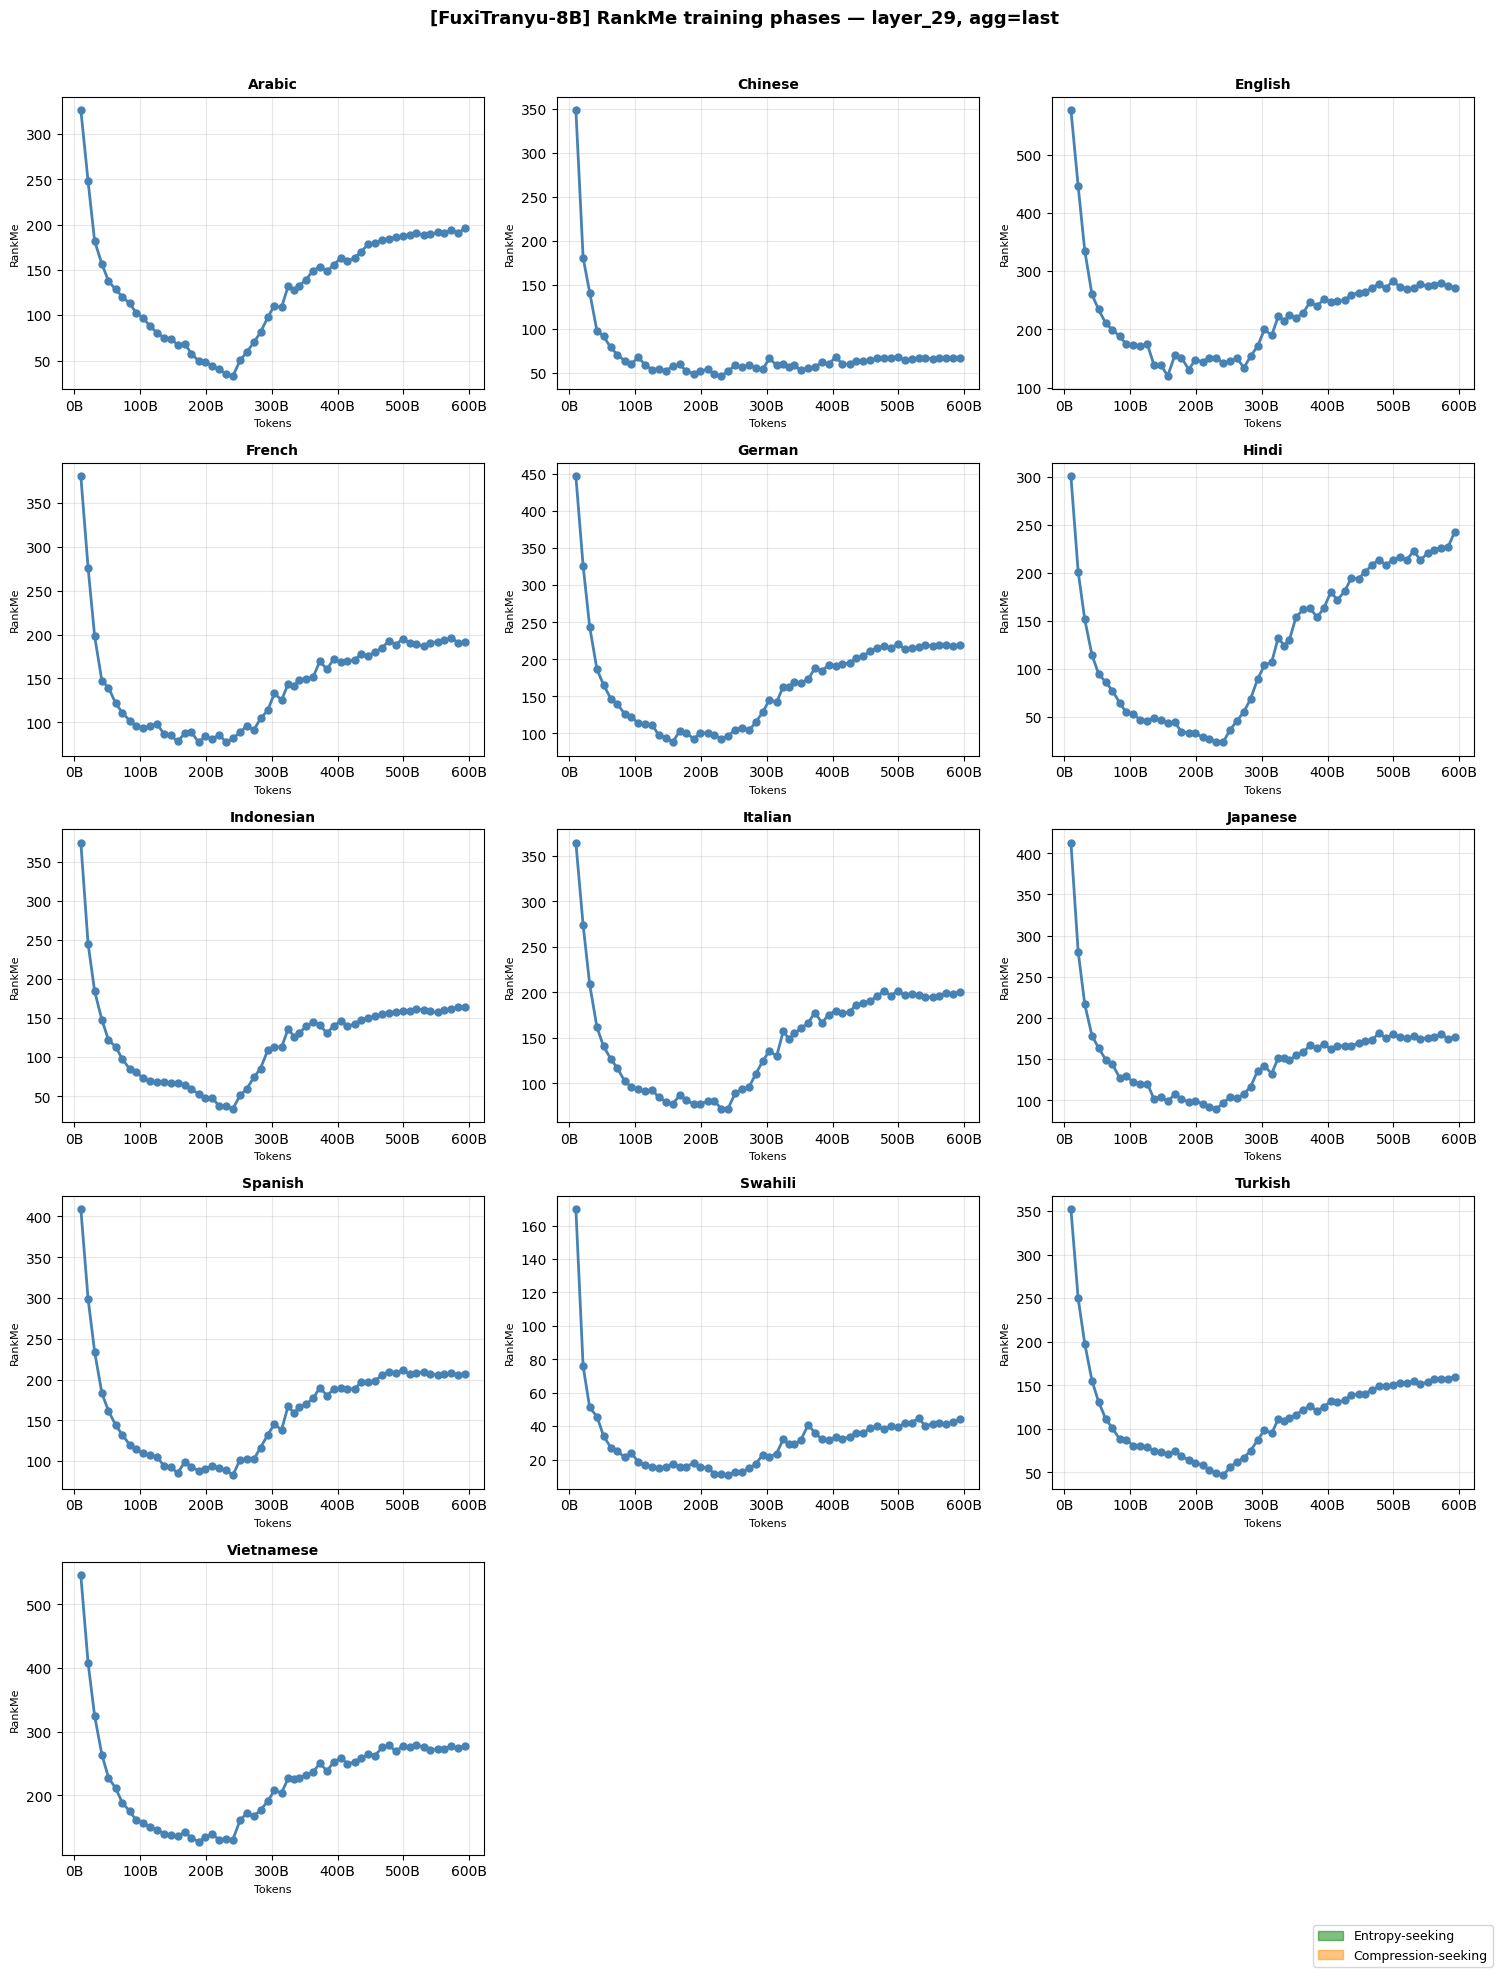

Saved: plots/rankme_phases.png


In [5]:
plot_rankme_phases(df_layer, df_phases, checkpoints_all, token_counts,
                   langs_sorted, MODEL_LABEL, LAYER, AGGREGATION, PLOTS_DIR)

In [6]:
if EVAL_AVAILABLE:
    df_grokking = compute_grokking(df_eval, TASK_LANGUAGES, RANDOM_CHANCE,
                                   threshold=GROKKING_THRESHOLD,
                                   min_consecutive=GROKKING_MIN_CONSEC)
    print(df_grokking.to_string(index=False))
else:
    df_grokking = pd.DataFrame()
    print("[INFO] No eval data — run submit_eval.sh + merge_results.py first.")

  task   language  grokking_tokens  peak_tokens  peak_accuracy  random_chance
m_mmlu    English             42.0         42.0            0.5           0.25
m_mmlu    Chinese            157.0        157.0            0.5           0.25
m_mmlu     German              NaN         42.0            1.0           0.25
m_mmlu    Spanish             42.0         42.0            0.5           0.25
m_mmlu    Italian              NaN         42.0            0.0           0.25
m_mmlu     Arabic              NaN         42.0            0.5           0.25
m_mmlu      Hindi              NaN        325.0            0.5           0.25
m_mmlu Indonesian              NaN        325.0            0.5           0.25
 xcopa    Chinese              NaN         42.0            0.0           0.50
 xcopa    Italian              NaN        325.0            0.5           0.50
 xcopa Vietnamese              NaN         42.0            0.5           0.50
 xcopa    Turkish              NaN         42.0            0.0  

In [7]:
if EVAL_AVAILABLE and not df_grokking.empty:
    df_correlations = compute_correlations_table(df_grokking, df_phases)
    print(df_correlations.to_string(index=False))
else:
    df_correlations = pd.DataFrame()
    print("[INFO] Skipping correlation analysis — no eval data available.")

  task            predictor (x)        outcome (y)  n  spearman_r  spearman_p  pearson_r  pearson_p
m_mmlu    Compression onset (B) Grokking onset (B)  0         NaN         NaN        NaN        NaN
m_mmlu    Compression onset (B)      Peak accuracy  8         NaN         NaN        NaN        NaN
m_mmlu Compression duration (B) Grokking onset (B)  0         NaN         NaN        NaN        NaN
m_mmlu Compression duration (B)      Peak accuracy  8         NaN         NaN        NaN        NaN
 xcopa    Compression onset (B) Grokking onset (B)  0         NaN         NaN        NaN        NaN
 xcopa    Compression onset (B)      Peak accuracy  5         NaN         NaN        NaN        NaN
 xcopa Compression duration (B) Grokking onset (B)  0         NaN         NaN        NaN        NaN
 xcopa Compression duration (B)      Peak accuracy  5         NaN         NaN        NaN        NaN


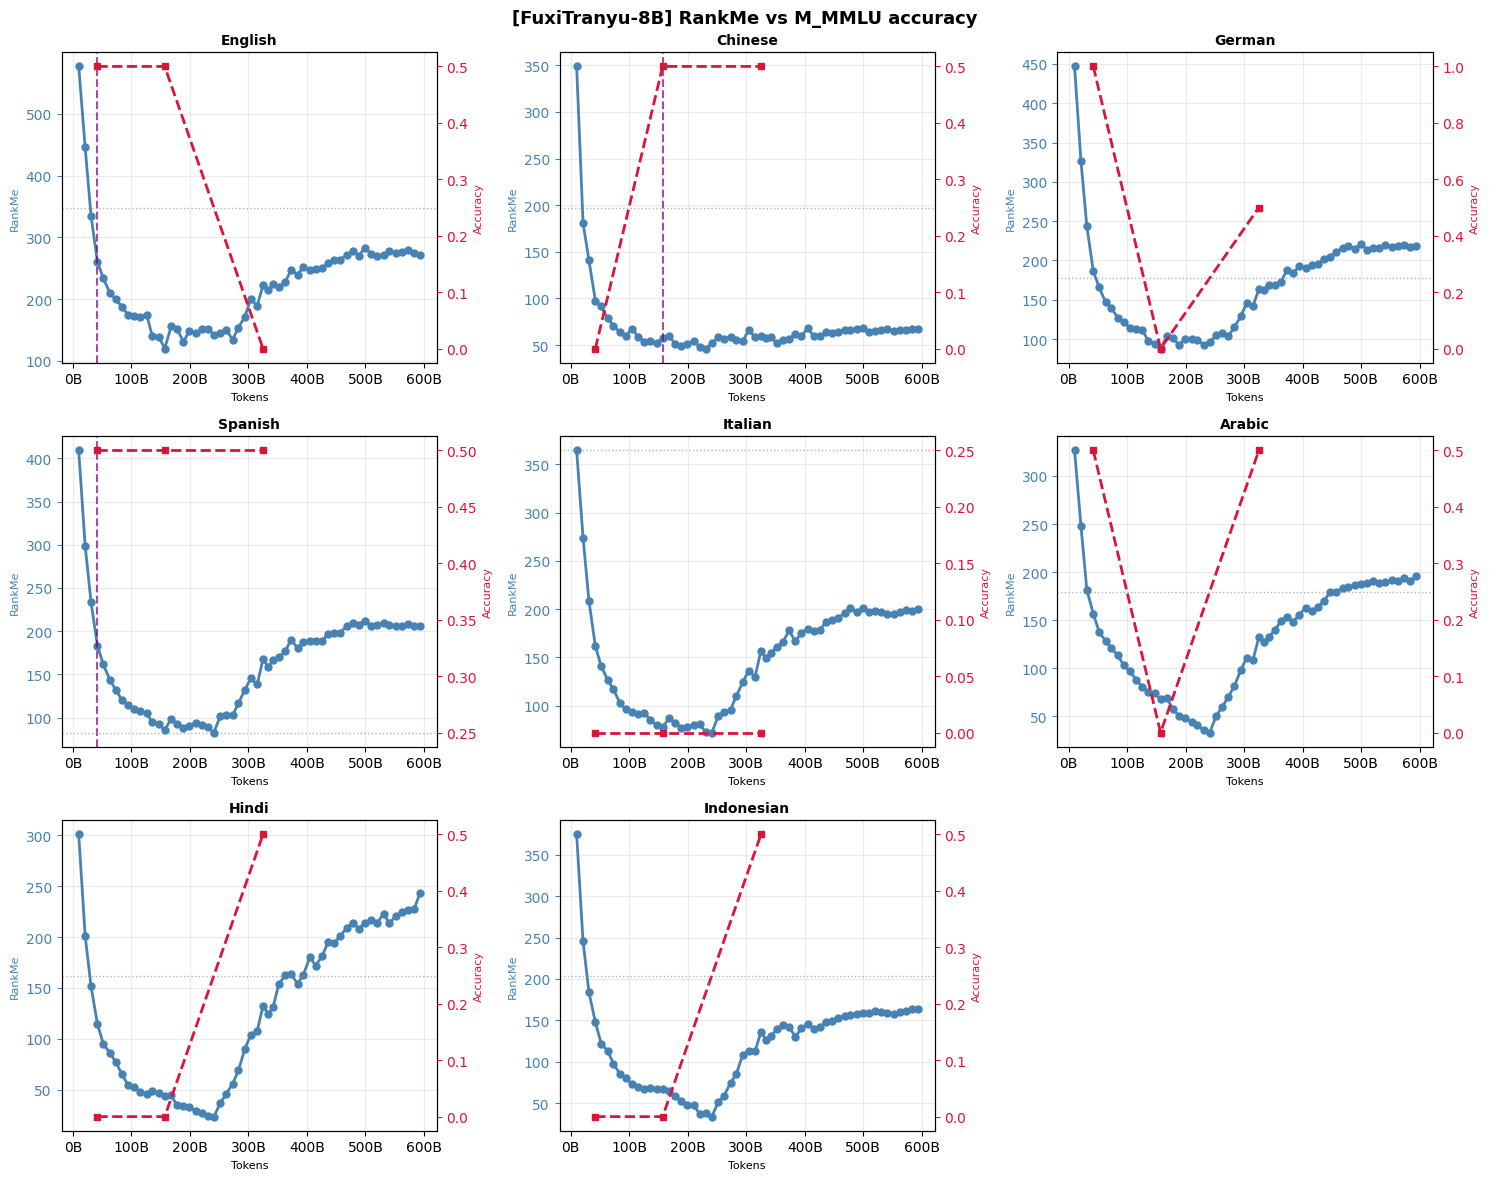

Saved: plots/overlay_m_mmlu.png


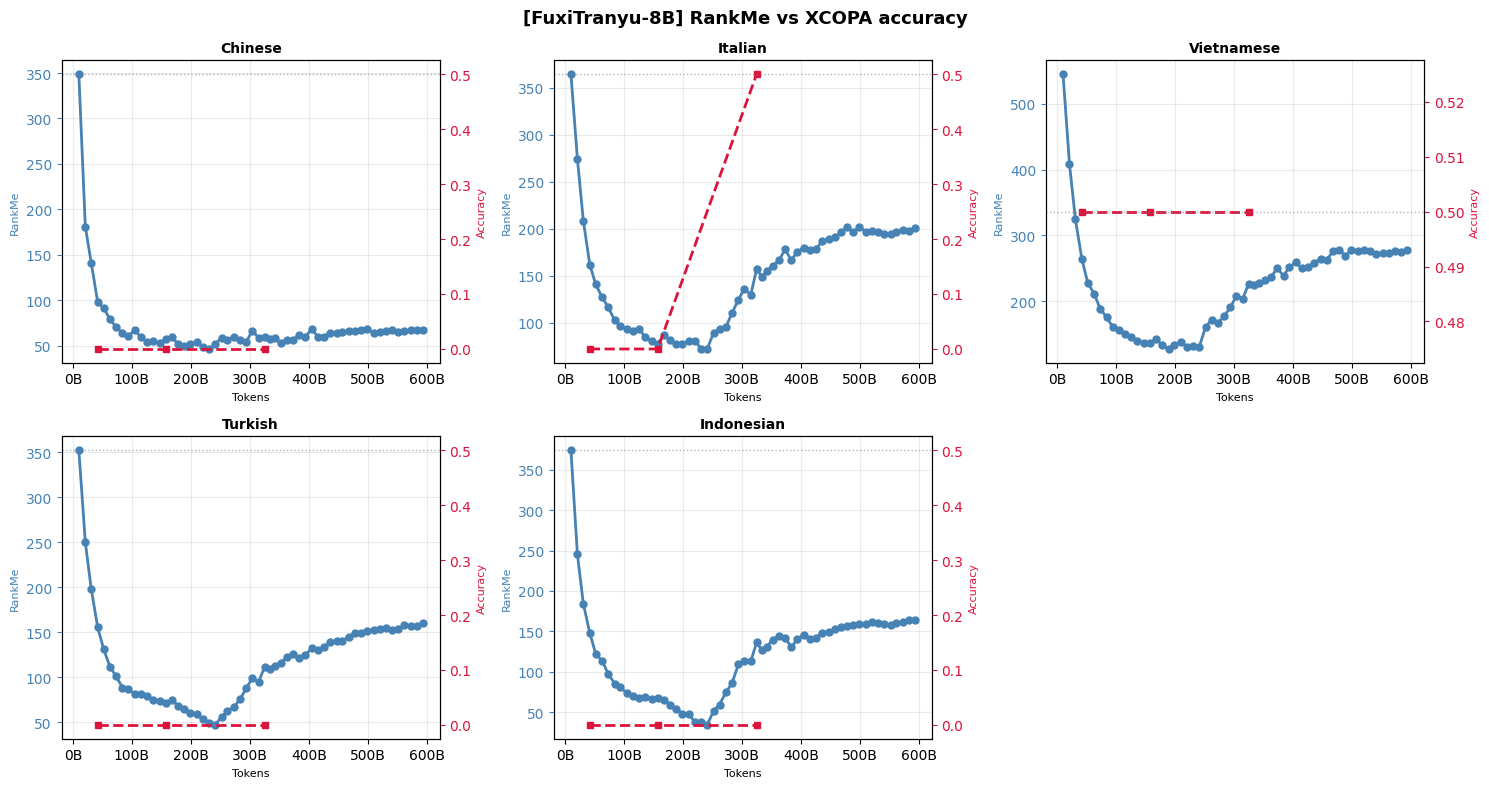

Saved: plots/overlay_xcopa.png


In [8]:
if EVAL_AVAILABLE:
    plot_overlay(df_eval, df_layer, df_phases, df_grokking, TASK_LANGUAGES, RANDOM_CHANCE,
                 checkpoints_all, token_counts, langs_sorted, MODEL_LABEL, PLOTS_DIR)
else:
    print("[INFO] Skipping overlay plots — run evaluate.py first.")

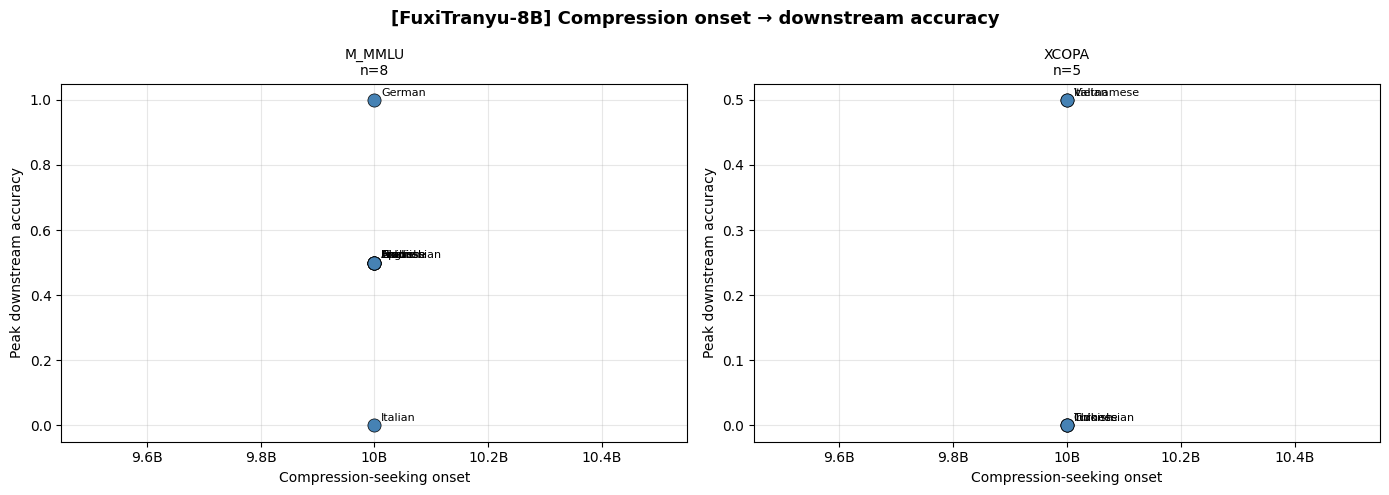

Saved: plots/correlation_scatter.png


In [9]:
if EVAL_AVAILABLE and not df_correlations.empty:
    plot_correlation_scatter(df_grokking, df_phases, MODEL_LABEL, PLOTS_DIR)
else:
    print("[INFO] Skipping correlation scatter — no eval data available.")

## Summary

### What runs with `fuxi.csv` alone (no eval needed)
- Phase identification: entropy-seeking / compression-seeking per language (Plot 1)
- Phase onset and duration table

### What requires downstream evaluation results (`fuxi_merged.csv`)
- Grokking detection — run `submit_eval.sh` + `merge_results.py` first
- Spearman / Pearson correlation: compression onset → accuracy
- Overlay plots: RankMe + accuracy + phase regions (Plot 2)
- Correlation scatter per task, m-MMLU vs XCOPA (Plot 3)

### Workflow
```bash
# 1 — Submit one cluster job per checkpoint (see README)
for ckpt in 10B 115B ...; do
    ./downstream_evaluation/submit_eval.sh $ckpt fuxi
done

# 2 — After all jobs complete, merge once manually (see README)

# 3 — Rerun this notebook — all cells activate automatically
```